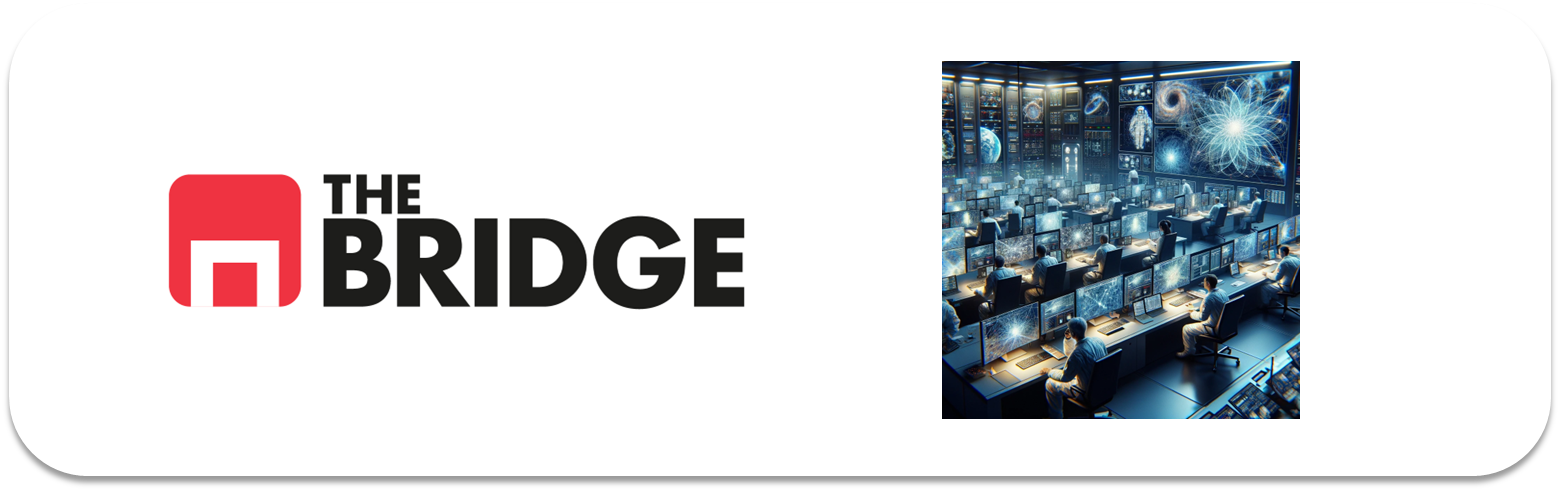

## PRACTICA OBLIGATORIA: **Redes Convolucionales**

* La práctica obligatoria de esta unidad consiste en un ejercicio de construcción de una red convolucional con Keras para la clasificación de imagenes de simpáticos perretes y gatetes. Descarga este notebook en tu ordenador y trabaja en local. Ten en cuenta que tendrás que descar los directorios de imágenes y datos adicionales, si los hubiera.
* Recuerda que debes subirla a tu repositorio personal antes de la sesión en vivo para que puntúe adecuadamente.  
* Recuerda también que no es necesario que esté perfecta, sólo es necesario que se vea el esfuerzo. 
* Esta práctica se resolverá en la sesión en vivo correspondiente y la solución se publicará en el repo del curso. 

### Ejercicio 0

Importa los paquetes y módulos que necesites a lo largo del notebook.

In [2]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

### Problema de Negocio y dataset

Una conocida empresa de información inmobiliaria utiliza un CAPTCHA visual de perros y gatos para detectar webscrappings intensivos y ataques de denegación de servicio. Últimamente, ha detectado que su sistema está empezando a flojear, es decir que hay muchos sistemas de detección automática de imágenes que son capaces de detectar que es un perro y un gato y salterse el CAPTCHA antirobots. Por eso nos ha pedido que entrenemos un modelo potente de clasificación que emule a estos sistemas con el objetivo de emplear como fotografías para el CAPTCHA aquellas que no sepa detectar este sistema emulador de chicos malos.  

Pues manos a la obra, tenemos que seleccionar en un conjunto de 1000 imágenes aquellas que peor se le daría clasificar a un potencial sistema anti-CAPTCHA.  

Para ello vamos a emplear un conjunto de train de 4000 imágenes de perretes y gatetes que se encuentran distribuidas en "data" en cuatro directorios "github_train_0",  "github_train_1", "githun_train_2" y "github_train_3". Los datos de las imagenes que tenemos que clasificar y luego seleccionar como las más "difíciles" están en "data" en el directorio "github_test".


### Se pide

1. Crear los datasets X,y de train y test, leyendo las imágenes de los directorios correspondientes (tendrás que leer todas las imágenes de los cuatro directorios para train) y a la vez que se leen adpatar su resolución para que todas tengan un tamaño de 32x32. En este caso puedes adaptar las funciones de los ejercicios de la unidad. NOTA: Ten en cuenta que la clase a la que pertenece en la foto está en el nombre del archivo.

2. Crea un modelo DL basado en redes convolucionales con al menos dos juegos Convolucional-Pooling. Sigue todo el proceso de ML (visualización del dataset, MiniEDA, Construcción del modelo)

3. Entrenar el modelo con un callback de Earlystopping con paciencia la que tengas :-). Muestra su historial de entrenamiento.

4. Evalua el modelo, haz un reporte de clasificacion y muestra la matriz de confianza.

5. Es el momento de seleccionar las imagenes: Selecciona el 10% de imágenes mal clasificadas de una y otra clase que tengan el mayor nivel de confianza de que pertenencían a la clase errónea. Es decir las imágenes de perros clasificadas como gatos y con la probabilidad de ser perror más alta.


### Extra (para hacer en clase)

Repite los pasos 3 a 5 utilizando el generador de imágenes sintéticas o Image Augmentation de Keras. 



In [3]:
import os

# ruta base
base_path = "./data"

# carpetas de train
train_dirs = [
    os.path.join(base_path, "github_train_0"),
    os.path.join(base_path, "github_train_1"),
    os.path.join(base_path, "github_train_2"),
    os.path.join(base_path, "github_train_3"),
]

# carpeta test
test_dir = os.path.join(base_path, "github_test")

print("Train dirs:")
for d in train_dirs:
    print(d, "-> existe:", os.path.exists(d))

print("\nTest dir:")
print(test_dir, "-> existe:", os.path.exists(test_dir))

Train dirs:
./data\github_train_0 -> existe: True
./data\github_train_1 -> existe: True
./data\github_train_2 -> existe: True
./data\github_train_3 -> existe: True

Test dir:
./data\github_test -> existe: True


In [9]:
# Para hacer este punto utilice chat, ya que no me entero de la peli aun....
import cv2

# ---------- FUNCIÓN PARA LEER IMÁGENES ----------
def cargar_imagenes_desde_carpetas(lista_carpetas, size=(32, 32)):
    X = []
    y = []
    
    for carpeta in lista_carpetas:
        for archivo in os.listdir(carpeta):
            ruta = os.path.join(carpeta, archivo)
            
            # evitar archivos raros
            if not os.path.isfile(ruta):
                continue
            
            # leer imagen
            img = cv2.imread(ruta)
            if img is None:
                continue
            
            # convertir BGR -> RGB
            img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
            
            # redimensionar a 32x32
            img = cv2.resize(img, size)
            
            # etiqueta desde el nombre del archivo
            nombre = archivo.lower()
            if "dog" in nombre or "perro" in nombre:
                label = 1
            elif "cat" in nombre or "gato" in nombre:
                label = 0
            else:
                continue
            
            X.append(img)
            y.append(label)
    
    return np.array(X), np.array(y)

# ---------- RUTAS ----------
base_path = "./data"

train_dirs = [
    os.path.join(base_path, "github_train_0"),
    os.path.join(base_path, "github_train_1"),
    os.path.join(base_path, "github_train_2"),
    os.path.join(base_path, "github_train_3"),
]

test_dirs = [
    os.path.join(base_path, "github_test")
]

# ---------- CARGAR DATASETS ----------
X_train, y_train = cargar_imagenes_desde_carpetas(train_dirs, size=(32, 32))
X_test, y_test = cargar_imagenes_desde_carpetas(test_dirs, size=(32, 32))

print("Clases train:", np.unique(y_train, return_counts=True))
print("Clases test:", np.unique(y_test, return_counts=True))

Clases train: (array([0, 1]), array([2000, 2000]))
Clases test: (array([0, 1]), array([500, 500]))


In [5]:
X_train.size

12288000

In [6]:
X_train[0]

array([[[126, 100,  64],
        [118,  92,  53],
        [129, 104,  63],
        ...,
        [ 88,  69,  45],
        [ 98,  40,  25],
        [121,  72,  50]],

       [[113,  92,  61],
        [122, 102,  68],
        [131, 111,  75],
        ...,
        [131,  75,  57],
        [ 99,  53,  23],
        [ 99,  42,  22]],

       [[120,  96,  64],
        [133, 110,  74],
        [126, 103,  63],
        ...,
        [ 79,  25,  12],
        [ 50,  12,   2],
        [ 79,  32,   6]],

       ...,

       [[ 15,  15,  10],
        [ 82,  79,  69],
        [ 73,  67,  51],
        ...,
        [103,  95,  69],
        [ 83,  75,  53],
        [ 98,  92,  60]],

       [[ 97,  99,  88],
        [ 66,  63,  49],
        [ 80,  69,  51],
        ...,
        [ 70,  61,  39],
        [ 88,  79,  61],
        [100,  92,  68]],

       [[ 63,  55,  44],
        [ 64,  55,  39],
        [ 82,  71,  50],
        ...,
        [ 86,  72,  46],
        [116, 101,  77],
        [ 94,  82,  55]]

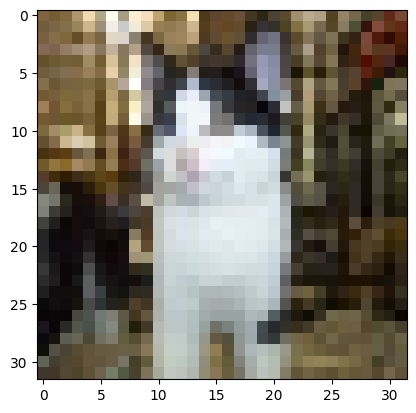

In [7]:
plt.imshow(X_train[0]);
plt.show()

2. Crea un modelo DL basado en redes convolucionales con al menos dos juegos Convolucional-Pooling. Sigue todo el proceso de ML (visualización del dataset, MiniEDA, Construcción del modelo)

In [ ]:

print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

X_train: (4000, 32, 32, 3)
X_test: (1000, 32, 32, 3)
y_train: (4000,)
y_test: (1000,)


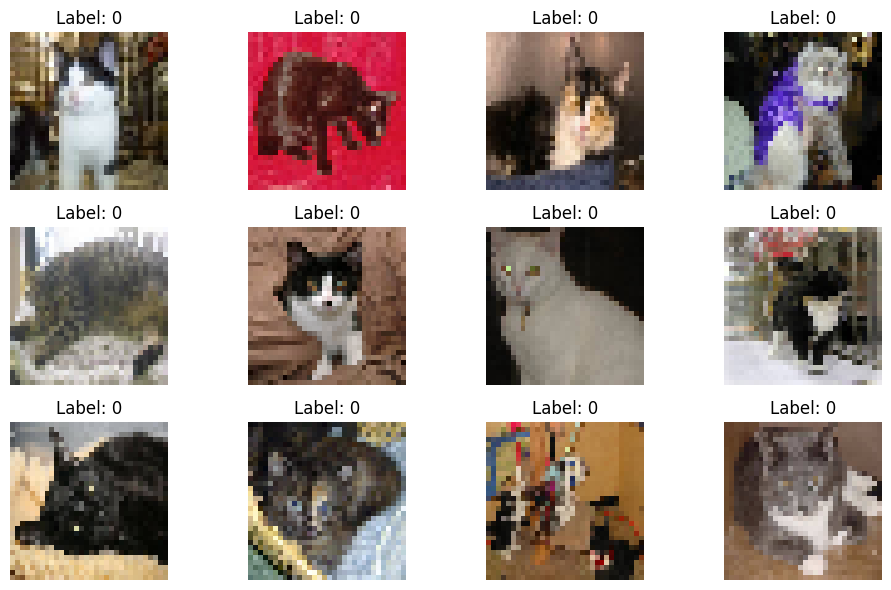

In [10]:
plt.figure(figsize=(10,6))

for i in range(12):
    plt.subplot(3,4,i+1)
    plt.imshow(X_train[i])
    plt.title(f"Label: {y_train[i]}")
    plt.axis("off")

plt.tight_layout()
plt.show()

#### MiniEDA

In [11]:
print("Clases únicas en train:", np.unique(y_train))
print("Clases únicas en test:", np.unique(y_test))
print("Proporción train:")
print(pd.Series(y_train).value_counts(normalize=True))

Clases únicas en train: [0 1]
Clases únicas en test: [0 1]
Proporción train:
0    0.5
1    0.5
Name: proportion, dtype: float64


In [12]:
print(pd.Series(y_train).value_counts())
print(pd.Series(y_test).value_counts())

0    2000
1    2000
Name: count, dtype: int64
0    500
1    500
Name: count, dtype: int64


In [13]:
#Me miro los rangos
print("Min train:", X_train.min())
print("Max train:", X_train.max())
print("Shape de una imagen:", X_train[0].shape)

Min train: 0
Max train: 255
Shape de una imagen: (32, 32, 3)


### 3. Construcción del modelo CNN

In [14]:
#Este codigo lo saque de chat ya que no sabia bien como plantearlo
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, Conv2D, MaxPooling2D, Flatten, Dense, Dropout

model = Sequential([
    Input(shape=(32, 32, 3)),
    
    Conv2D(32, (3,3), activation='relu', padding='same'),
    MaxPooling2D((2,2)),
    
    Conv2D(64, (3,3), activation='relu', padding='same'),
    MaxPooling2D((2,2)),
    
    Flatten(),
    Dense(128, activation='relu'),
    Dropout(0.3),
    Dense(1, activation='sigmoid')
])

In [15]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 4096)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       524,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 543,937 (2.07 MB)

 Trainable params: 543,937 (2.07 MB)

 Non-trainable params: 0 (0.00 B)

- Total params: 543,937 -> Ese es el total de parámetros que el modelo tiene que aprender.

- Non-trainable params: 0 -> No hay parámetros congelados.

In [16]:
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

In [17]:
# Entrenamos

history = model.fit(
    X_train,
    y_train,
    validation_split=0.2,
    epochs=10,
    batch_size=32
)

Epoch 1/10
100/100 ━━━━━━━━━━━━━━━━━━━━ 6s 32ms/step - accuracy: 0.5850 - loss: 5.8811 - val_accuracy: 0.0637 - val_loss: 0.9656
Epoch 2/10
100/100 ━━━━━━━━━━━━━━━━━━━━ 3s 29ms/step - accuracy: 0.6247 - loss: 0.6428 - val_accuracy: 0.0550 - val_loss: 1.1005
Epoch 3/10
100/100 ━━━━━━━━━━━━━━━━━━━━ 3s 28ms/step - accuracy: 0.6728 - loss: 0.5969 - val_accuracy: 0.1912 - val_loss: 1.0501
Epoch 4/10
100/100 ━━━━━━━━━━━━━━━━━━━━ 3s 29ms/step - accuracy: 0.7050 - loss: 0.5427 - val_accuracy: 0.1650 - val_loss: 1.3873
Epoch 5/10
100/100 ━━━━━━━━━━━━━━━━━━━━ 3s 32ms/step - accuracy: 0.7472 - loss: 0.5068 - val_accuracy: 0.5788 - val_loss: 0.7650
Epoch 6/10
100/100 ━━━━━━━━━━━━━━━━━━━━ 3s 31ms/step - accuracy: 0.7709 - loss: 0.4537 - val_accuracy: 0.5913 - val_loss: 0.7803
Epoch 7/10
100/100 ━━━━━━━━━━━━━━━━━━━━ 3s 31ms/step - accuracy: 0.8028 - loss: 0.4164 - val_accuracy: 0.3837 - val_loss: 1.2773
Epoch 8/10
100/100 ━━━━━━━━━━━━━━━━━━━━ 3s 32ms/step - accuracy: 0.8284 - loss: 0.3714 - val_accu

In [18]:
# Evaluamos
test_loss, test_acc = model.evaluate(X_test, y_test)
print("Test loss:", test_loss)
print("Test accuracy:", test_acc)

32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.6590 - loss: 0.8842
Test loss: 0.8842366933822632
Test accuracy: 0.6589999794960022


In [19]:
#Predecimos

y_pred_prob = model.predict(X_test)
y_pred = (y_pred_prob > 0.5).astype(int).ravel()

32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step


In [20]:
from sklearn.metrics import confusion_matrix, classification_report

print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))

[[387 113]
 [228 272]]
              precision    recall  f1-score   support

           0       0.63      0.77      0.69       500
           1       0.71      0.54      0.61       500

    accuracy                           0.66      1000
   macro avg       0.67      0.66      0.65      1000
weighted avg       0.67      0.66      0.65      1000



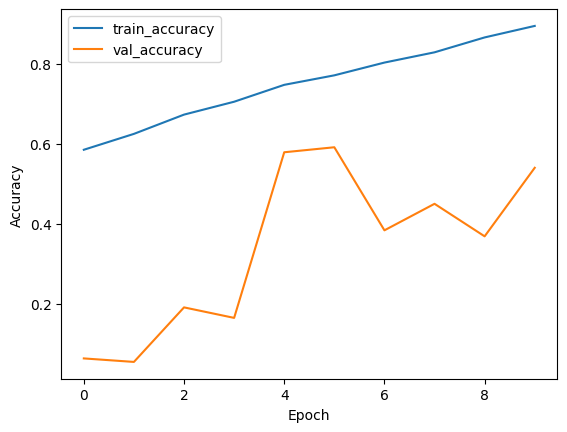

In [21]:
plt.plot(history.history['accuracy'], label='train_accuracy')
plt.plot(history.history['val_accuracy'], label='val_accuracy')
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

- Vale, vemos un overfitting en la curva de entrenamiento muestra una mejora progresiva de la accuracy en el conjunto de train. Pero la accuracy de validación presenta una evolución irregular y tambien inferior, el modelo no generaliza de forma estable sobre datos no vistos. 

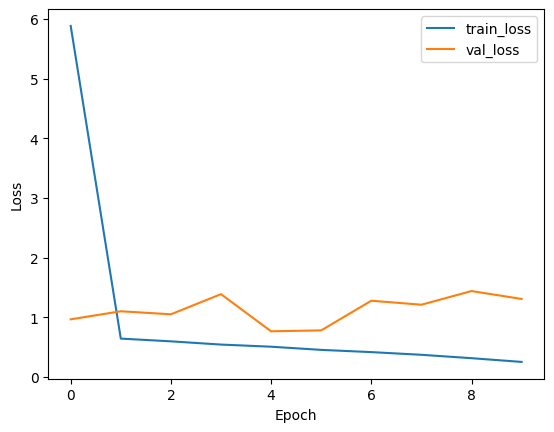

In [22]:
plt.plot(history.history['loss'], label='train_loss')
plt.plot(history.history['val_loss'], label='val_loss')
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.show()

Intentare solucionarlo..

In [23]:
from sklearn.model_selection import train_test_split
from tensorflow.keras.callbacks import EarlyStopping

X_train_sub, X_val, y_train_sub, y_val = train_test_split(
    X_train,
    y_train,
    test_size=0.2,
    random_state=42,
    stratify=y_train
)

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True
)

In [24]:
history = model.fit(
    X_train_sub,
    y_train_sub,
    validation_data=(X_val, y_val),
    epochs=20,
    batch_size=32,
    callbacks=[early_stop]
)

Epoch 1/20
100/100 ━━━━━━━━━━━━━━━━━━━━ 3s 31ms/step - accuracy: 0.7956 - loss: 0.4462 - val_accuracy: 0.7775 - val_loss: 0.4907
Epoch 2/20
100/100 ━━━━━━━━━━━━━━━━━━━━ 5s 29ms/step - accuracy: 0.8328 - loss: 0.3816 - val_accuracy: 0.8250 - val_loss: 0.4466
Epoch 3/20
100/100 ━━━━━━━━━━━━━━━━━━━━ 3s 28ms/step - accuracy: 0.8628 - loss: 0.3095 - val_accuracy: 0.7962 - val_loss: 0.4518
Epoch 4/20
100/100 ━━━━━━━━━━━━━━━━━━━━ 3s 27ms/step - accuracy: 0.8891 - loss: 0.2597 - val_accuracy: 0.8375 - val_loss: 0.4225
Epoch 5/20
100/100 ━━━━━━━━━━━━━━━━━━━━ 4s 37ms/step - accuracy: 0.9087 - loss: 0.2173 - val_accuracy: 0.7887 - val_loss: 0.6140
Epoch 6/20
100/100 ━━━━━━━━━━━━━━━━━━━━ 3s 30ms/step - accuracy: 0.9309 - loss: 0.1647 - val_accuracy: 0.8000 - val_loss: 0.5455
Epoch 7/20
100/100 ━━━━━━━━━━━━━━━━━━━━ 3s 31ms/step - accuracy: 0.9372 - loss: 0.1622 - val_accuracy: 0.8000 - val_loss: 0.5386


In [25]:
# Evaluamos
test_loss, test_acc = model.evaluate(X_test, y_test)
print("Test loss:", test_loss)
print("Test accuracy:", test_acc)

32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.6620 - loss: 0.8512
Test loss: 0.8511525392532349
Test accuracy: 0.6620000004768372


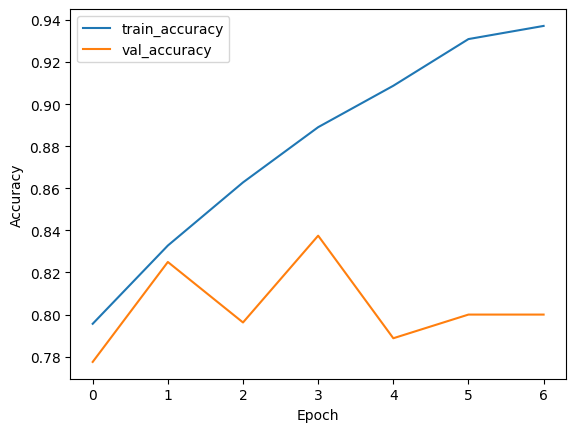

In [26]:
plt.plot(history.history['accuracy'], label='train_accuracy')
plt.plot(history.history['val_accuracy'], label='val_accuracy')
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

- ``train_accuracy`` sube de forma continua

- ``val_accuracy`` se mantiene en un rango bastante bueno: aprox 0.78–0.84

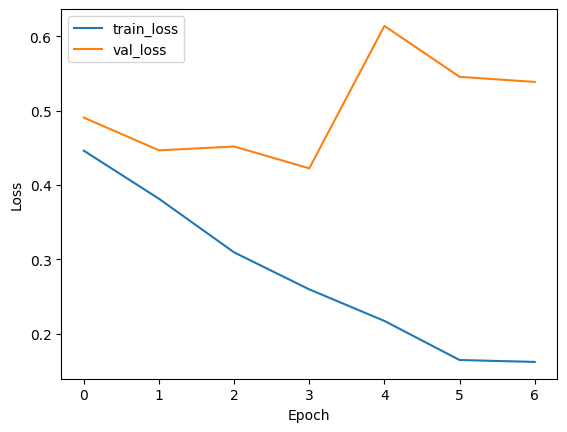

In [27]:
plt.plot(history.history['loss'], label='train_loss')
plt.plot(history.history['val_loss'], label='val_loss')
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.show()

### Evaluamos el modelo

In [31]:
test_loss, test_acc = model.evaluate(X_test, y_test)
print("Test loss:", test_loss)
print("Test accuracy:", test_acc)

32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.6620 - loss: 0.8512
Test loss: 0.8511525392532349
Test accuracy: 0.6620000004768372


- En el conjunto de test, el modelo obtuvo una accuracy de 0.662 y una loss de 0.851, logrando una mejor capacidad de clasificación sobre imágenes no vistas. Pero en el valor de la loss y las curvas de entrenamiento sugieren que todavía existe margen de mejora en la generalización del modelo.

In [33]:
y_pred_prob = model.predict(X_test)
y_pred = (y_pred_prob > 0.5).astype(int).ravel()

32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step


In [34]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.68      0.61      0.64       500
           1       0.65      0.71      0.68       500

    accuracy                           0.66      1000
   macro avg       0.66      0.66      0.66      1000
weighted avg       0.66      0.66      0.66      1000



In [35]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)
print(cm)

[[305 195]
 [143 357]]


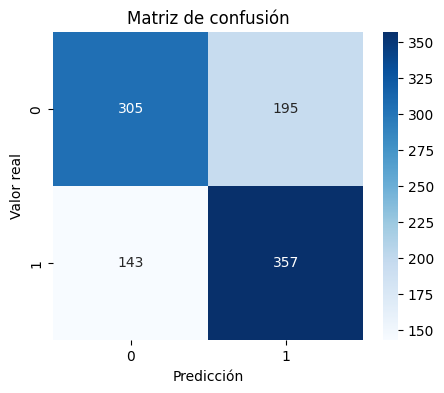

In [36]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicción")
plt.ylabel("Valor real")
plt.title("Matriz de confusión")
plt.show()

En la matriz de confusión vemos que el modelo clasificó correctamente 305 ejemplos de la clase 0 y 357 ejemplos de la clase 1. Sin embargo, también cometió 195 errores al predecir como clase 1 ejemplos que en realidad pertenecían a la clase 0, y 143 errores al clasificar como clase 0 ejemplos de la clase 1. Estos resultados nos dicen que el modelo tiene un comportamiento relativamente equilibrado, aunque presenta una mejor capacidad para detectar la clase 1 que la clase 0.